# Program - modify-DYCOMSrf01_rf02-IC_4scam.ipynb

**Purpose**

Modify DYCOMS RF01 and RF02 SCM input

**Content**
- compute RF01 and RF02 profiles from references
- Modify RF01: (1) change u=6 m/s and v=-4.25 m/s to be consistent with RF01 formula; (2) remove supersaturation when q>qs
- plot XY profiles

**Author:** Yi-Hsuan Chen (yihsuan@umich.edu)

**Date:** 
May 2025

**Reference program:**



In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import io, os, sys, types

import yhc_module as yhc

xr.set_options(keep_attrs=True)  # keep attributes after xarray operation

ERROR 1: PROJ: proj_create_from_database: Open of /lfs/opt/anaconda3/share/proj failed


# Functions

## theta_l_to_T_qv_ql

In [2]:
import numpy as np

# Constants
Rd = 287.04       # gas constant for dry air (J/kg/K)
Rv = 461.5        # gas constant for water vapor (J/kg/K)
Cp = 1005.7       # specific heat of dry air at constant pressure (J/kg/K)
Lv = 2.5e6        # latent heat of vaporization (J/kg)
epsilon = Rd / Rv

def saturation_vapor_pressure(T):
    """Calculate saturation vapor pressure over liquid water (Pa)"""
    T = np.asarray(T)
    return 610.94 * np.exp((17.625 * (T - 273.15)) / (T - 30.11))

def saturation_specific_humidity(p, T):
    """Compute saturation specific humidity (kg/kg)"""
    p = np.asarray(p)
    T = np.asarray(T)
    e_s = saturation_vapor_pressure(T)
    return epsilon * e_s / (p - (1 - epsilon) * e_s)

def theta_l_to_T_qv_ql(theta_l, q_t, p, tol=1e-6, max_iter=100):
    """
    Convert theta_l and q_t to T, q_v, and q_l using iterative saturation adjustment.

    Parameters:
        theta_l: liquid water potential temperature (K)
        q_t: total water mixing ratio (kg/kg)
        p: pressure (Pa)

    Returns:
        T: temperature (K)
        q_v: specific humidity (kg/kg)
        q_l: liquid water mixing ratio (kg/kg)
    """
    # Ensure array compatibility
    theta_l = np.asarray(theta_l)
    q_t = np.asarray(q_t)
    p = np.asarray(p)

    # Initial guess for T (assume no liquid water)
    T = theta_l * (p / 1e5) ** (Rd / Cp)

    alpha = 0.5  # damping factor between 0 (no update) and 1 (full update)

    for _ in range(max_iter):
        q_vs = saturation_specific_humidity(p, T)
        q_v = np.minimum(q_t, q_vs)
        q_l = np.maximum(q_t - q_vs, 0.0)

        T_update = theta_l * (p / 1e5) ** (Rd / Cp) + (Lv / Cp) * q_l
        T_new = (1 - alpha) * T + alpha * T_update
        #print("T, T_new", T, T_new)

        if np.all(np.abs(T_new - T) < tol):
            break

        T = T_new.copy()

    return T, q_v, q_l

#-----------
# do test
#-----------
do_test = "112"
if (do_test == "111"):
    theta_l = 289
    q_t = 20e-3
    p = 1000e2
    T, q_v, q_l = theta_l_to_T_qv_ql(theta_l, q_t, p)
    print(T, q_v, q_l)
    print(saturation_specific_humidity(p, T))

## RF01 & RF02 profiles

### RF01
Stevens, B., Moeng, C.-H., Ackerman, A. S., Bretherton, C. S., Chlond, A., de Roode, S., Edwards, J., Golaz, J. C., Jiang, H., Khairoutdinov, M., Kirkpatrick, M. P., Lewellen, D. C., Lock, A., Müller, F., Stevens, D. E., Whelan, E., & Zhu, P. (2005). Evaluation of large-eddy simulations via observations of nocturnal marine stratocumulus. Monthly Weather Review, 133(6), 1443–1462. https://doi.org/10.1175/MWR2930.1

### RF02
Wyant, M. C., Bretherton, C. S., Chlond, A., Griffin, B. M., Kitagawa, H., Lappen, C. L., Larson, V. E., Lock, A., Park, S., de Roode, S. R., Uchida, J., Zhao, M., & Ackerman, A. S. (2007). A single-column model intercomparison of a heavily drizzling stratocumulus-topped boundary layer. Journal of Geophysical Research Atmospheres, 112(24). https://doi.org/10.1029/2007JD008536

In [3]:
###################
###################
###################
def RF01_profiles(z, z_i=840, div=3.75e-6, p_surface=1017.8e2):

    # Convert z (height) to pressure (p) using the hypsometric equation
    R = 287.05  # specific gas constant for dry air (J/kg·K)
    g = 9.81    # gravitational acceleration (m/s²)
    L = 2.5e6   # Latent heat of vaporization (J/kg)
    M = 28.97   # Molar mass of air (kg/mol)
    cp_air = 1005 # specific heat of air, units: J/kg/K
    
    # Initialize theta_l with default value
    theta_l = np.full_like(z, 289.0, dtype=np.float64)
    above_zi = z > z_i
    theta_l[above_zi] = 297.5 + (z[above_zi] - z_i) ** (1/3)

    # Compute q_t
    q_t = np.where(z <= z_i, 9.0e-3, 1.5e-3)  # kg/kg

    # Constant wind profiles
    u = np.full_like(z, 6.0, dtype=np.float64)       # m/s
    v = np.full_like(z, -4.25, dtype=np.float64)     # m/s  

    # Compute w
    w = np.zeros_like(z, dtype=np.float64)
    for i in range(1, len(z)):
        dz = z[i] - z[i - 1]
        w[i] = w[i - 1] - div * dz  # Minus sign from continuity equation   

    T_surface = 289.0 * (p_surface/1000e2)**(R/cp_air) # Surface temperature (in Kelvin, example)

    return theta_l, q_t, u, v, w, T_surface, p_surface, div

###################
###################
###################
def RF02_profiles(z, z_i=795, div=3.75e-6, p_surface=1017.8e2):

    # Convert z (height) to pressure (p) using the hypsometric equation
    R = 287.05  # specific gas constant for dry air (J/kg·K)
    g = 9.81    # gravitational acceleration (m/s²)
    L = 2.5e6   # Latent heat of vaporization (J/kg)
    M = 28.97   # Molar mass of air (kg/mol)
    cp_air = 1005 # specific heat of air, units: J/kg/K

    # Initialize theta_l with default value
    theta_l = np.full_like(z, 288.3, dtype=np.float64)
    above_zi = z >= z_i
    theta_l[above_zi] = 295 + (z[above_zi] - z_i) ** (1/3)
    
    # Compute q_t (converted to kg/kg from g/kg)
    q_t = np.full_like(z, 9.45e-3, dtype=np.float64)
    q_t[above_zi] = (5 - 3 * (1 - np.exp((z_i - z[above_zi]) / 500))) * 1e-3  # kg/kg
    
    # Wind profiles (u and v in m/s)
    u = 3 + 4.3 * z / 1000
    v = -9 + 5.6 * z / 1000

    # Compute w
    w = np.zeros_like(z, dtype=np.float64)
    for i in range(1, len(z)):
        dz = z[i] - z[i - 1]
        w[i] = w[i - 1] - div * dz  # Minus sign from continuity equation   

    T_surface = 289.0 * (p_surface/1000e2)**(R/cp_air) # Surface temperature (in Kelvin, example)

    return theta_l, q_t, u, v, w, T_surface, p_surface, div

###################
###################
###################
def DYCOMS_RF_profiles(z, RF_choice):
    """
    Compute theta_l, q_t, u, v, T, q_v, q_l profiles based on height array z and inversion height z_i.
    
    Parameters:
        z (array-like): 1D array of height values (in meters).
        z_i (float): Inversion height (in meters).
        p_surface (float): Surface pressure (in hPa).
        
    Returns:
        dict: Dictionary with keys 'theta_l', 'q_t', 'u', 'v', 'T', 'q_v', 'q_l'.
    """
    z = np.asarray(z)

    # Convert z (height) to pressure (p) using the hypsometric equation
    R = 287.05  # specific gas constant for dry air (J/kg·K)
    g = 9.81    # gravitational acceleration (m/s²)
    L = 2.5e6   # Latent heat of vaporization (J/kg)
    M = 28.97   # Molar mass of air (kg/mol)
    cp_air = 1005 # specific heat of air, units: J/kg/K

    #
    if (RF_choice == "RF01"):
        theta_l, q_t, u, v, w, T_surface, p_surface, div = RF01_profiles(z)
    elif (RF_choice == "RF02"):
        theta_l, q_t, u, v, w, T_surface, p_surface, div = RF02_profiles(z)
    else:
        raise ValueError(f"Unsupported RF_choice: {RF_choice}")
    
    # compute vertical velocity
    p = np.zeros_like(z, dtype=np.float64)
    T = np.zeros_like(z, dtype=np.float64)
    q_v = np.zeros_like(z, dtype=np.float64)
    q_l = np.zeros_like(z, dtype=np.float64)
    omega = np.zeros_like(z, dtype=np.float64)

    # surface properties
    T[0] = T_surface
    p[0] = p_surface
    q_v[0] = q_t[0]
    q_l[0] = 0

    # compute pressure levels
    for i in range(1, len(z)):
        T[i] = T[i-1]
        dz = z[i] - z[i - 1]
        p[i] = p[i-1] * np.exp(-(g * dz) / (R * T[i]))
        #print(theta_l[i], q_t[i], p[i])
        T[i], q_v[i], q_l[i] = theta_l_to_T_qv_ql(theta_l[i], q_t[i], p[i])
        #omega[i] = -p[i]*g / (R * T[i]) * w[i]
        #print(T[i], q_v[i], q_l[i])

    for i in range(1, len(z)):
        dp = p[i] - p[i - 1]
        omega[i] = omega[i - 1] - div * dp  # Minus sign from continuity equation    
    
    # Build xarray dataset
    ds = xr.Dataset(
        data_vars=dict(
            theta_l=(["z"], theta_l, {"units": "K", "long_name": "Liquid Water Potential Temperature"}),
            q_t=(["z"], q_t, {"units": "kg/kg", "long_name": "Total Water Mixing Ratio"}),
            u=(["z"], u, {"units": "m/s", "long_name": "Zonal Wind"}),
            v=(["z"], v, {"units": "m/s", "long_name": "Meridional Wind"}),
            w=(["z"], w, {"units": "m/s", "long_name": "Vertical Velocity"}),
            p=(["z"], p, {"units": "Pa", "long_name": "Pressure"}),
            T=(["z"], T, {"units": "K", "long_name": "Temperature"}),
            q_v=(["z"], q_v, {"units": "kg/kg", "long_name": "Water Vapor Mixing Ratio"}),
            q_l=(["z"], q_l, {"units": "kg/kg", "long_name": "Liquid Water Mixing Ratio"}),
            omega=(["z"], omega, {"units": "Pa/s", "long_name": "Vertical pressure velocity"}),
        ),
        coords=dict(
            z=(["z"], z, {"units": "m", "long_name": "Height"})
        ),
        attrs=dict(
            description="RF01 Initial Condition Profile"
        )
    )
    
    return ds
    
# Example usage:
#z = np.linspace(0, 2000, 500)
#z = np.arange(0,3000,5)
#ds_rf01 = DYCOMS_RF_profiles(z, RF_choice="RF01")
#ds_rf01['v']

## (outdates) plot_profiles_from_ds

## plot_profiles_from_multiple_ds

In [5]:
def plot_profiles_from_multiple_ds(axes, ds_list, lg_labels,
                                   yy_list, keys_to_plot_list,
                                   linestyles=['-'],
                                   markers=None):
    """
    Plot selected profiles from multiple xarray.Datasets on shared axes.

    Parameters:
        axes (list): List of matplotlib axes to plot on.
        ds_list (list of xarray.Dataset): Datasets to plot.
        lg_labels (list of str): Legend labels corresponding to each dataset.
        yy_list (list of str): Vertical coordinate keys for each dataset.
        keys_to_plot_list (list of list of str): Variable names to plot per dataset.
        markers (list of str, optional): Marker styles for each dataset.
    """
    import matplotlib.pyplot as plt

    # Define default colors (extend as needed)
    colors = {
        'theta_l': 'blue',
        'q_t': 'green',
        'u': 'purple',
        'v': 'orange',
        'w': 'gray',
        'T': 'red',
        'q_v': 'brown',
        'q_l': 'cyan'
    }

    num_ds = len(ds_list)
    if markers is None:
        markers = [None] * num_ds  # default: no marker

    for ds_idx, (ds, lg_label, yy, keys_to_plot) in enumerate(zip(ds_list, lg_labels, yy_list, keys_to_plot_list)):
        # Get vertical coordinate
        if yy in ds.coords:
            lev = ds.coords[yy].values
        elif yy in ds:
            lev = ds[yy].values
        else:
            raise ValueError(f"Unexpected vertical coordinate '{yy}' in dataset {ds_idx}")

        for key in keys_to_plot:
            if key not in ds:
                continue  # skip missing variables

            i = keys_to_plot.index(key)
            field = ds[key].values
            label = ds[key].attrs.get('long_name', key)
            xlabel = f"{label} [{ds[key].attrs.get('units', '')}]"
            color = colors.get(key, 'black')

            #print(lev)
            axes[i].plot(field, lev, label=lg_label, color=color, marker=markers[ds_idx], linestyle=linestyles[ds_idx])
            axes[i].set_xlabel(xlabel)
            axes[i].set_title(label)
            axes[i].grid(True)

            #if yy in ["p", "lev"]:
            #    axes[i].invert_yaxis()

    for ax in axes:
        ax.legend()
        if 'p' in yy_list:
            ax.invert_yaxis()
            #ax.set_ylim(800e2, 1020e2)

    plt.tight_layout()
    plt.show()


# Modify RF01
- remove supersaturation
- adjust u & v

## remove supersaturation & adjust u & v

In [64]:
filename = "./DYCOMSrf01_4day_4scam.nc"
ds_scm_orig = xr.open_dataset(filename, mask_and_scale=False)  ## add mask_and_scale=False to avoid the error "ValueError: could not convert string to float: '-9999.f'"
                                                               ## when using ds.to_netcdf()
ds_scm = ds_scm_orig.isel(lon=0, lat=0, time=0)
ds_scm_rf01_mod = ds_scm.copy()

#--- modify u and v to be consistent with RF01 profiles
ds_scm_rf01_mod['u'][:]=6
ds_scm_rf01_mod['v'][:]=-4.25

#--- remove supersaturation
for i in range(len(ds_scm_rf01_mod['lev'])):
    qs = saturation_specific_humidity(ds_scm_rf01_mod['lev'][i], ds_scm_rf01_mod['T'][i])  # scalar inputs, scalar output
    if ds_scm_rf01_mod['lev'][i] > 0 and ds_scm_rf01_mod['q'][i] > qs:
        #print(i, ds_scm_rf01_mod['lev'][i].values)
        ds_scm_rf01_mod['q'][i] = qs

#--- write out the modified RF01 file
#do_writeout = True
do_writeout = False
filename_new = "./DYCOMSrf01_4day_4scam_yhc20250509.nc"

if do_writeout:

    if os.path.exists(filename_new):
        raise FileExistsError(f"New write out File '{filename_new}' already exists.")
    
    vars_to_replace = ['u', 'v', 'q']
    
    # Create a new dataset where each variable is replaced
    ds_updated = ds_scm_orig.copy()
    
    for var in vars_to_replace:
        if var in ds_scm_rf01_mod:
            # Expand dimensions to match (time, lev, lat, lon)
            # Assuming you want the same value repeated across time, lat, lon
            data = ds_scm_rf01_mod[var]
            data_expanded = data.expand_dims({'time': ds_scm_orig.dims['time'],
                                              'lat': ds_scm_orig.dims['lat'],
                                              'lon': ds_scm_orig.dims['lon']})
            data_expanded = data_expanded.transpose('time', 'lev', 'lat', 'lon')
            ds_updated[var] = data_expanded

    ds_updated.attrs['Modifications']= '(1) change u=6 m/s and v=-4.25 m/s to be consistent with RF01 formula; (2) remove supersaturation when q>qs. 2025-05-09'
    ds_updated.attrs["Modifications_contact"]= "Yi-Hsuan Chen (yihsuanc@gate.sinica.edu.tw)"
    ds_updated.to_netcdf(filename_new)
    print(f"Create {filename_new}")

# Modify RF02
- make CLDLIQ=0

## make CLDLIQ=0

In [83]:
filename = "./DYCOMSrf02_48hr_4scam.nc"
ds_scm_orig = xr.open_dataset(filename, mask_and_scale=False)  ## add mask_and_scale=False to avoid the error "ValueError: could not convert string to float: '-9999.f'"
                                                               ## when using ds.to_netcdf()
ds_scm_rf02_mod = ds_scm_orig.copy()
ds_scm_rf02_mod['CLDLIQ'][:,:,:,:] = 0
#ds_scm_rf02_mod['CLDLIQ'].values

#--- write out the modified RF01 file
#do_writeout = True
do_writeout = False
filename_new = "./DYCOMSrf02_48hr_4scam_yhc20250509.nc"

if do_writeout:

    if os.path.exists(filename_new):
        raise FileExistsError(f"New write out File '{filename_new}' already exists.")

    ds_scm_rf02_mod.attrs['Modifications']= '(1) Reset CLDLIQ to zeros. 2025-05-09'
    ds_scm_rf02_mod.attrs["Modifications_contact"]= "Yi-Hsuan Chen (yihsuanc@gate.sinica.edu.tw)"
    ds_scm_rf02_mod.to_netcdf(filename_new)
    print(f"Create {filename_new}")

# Plots

## RF01

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


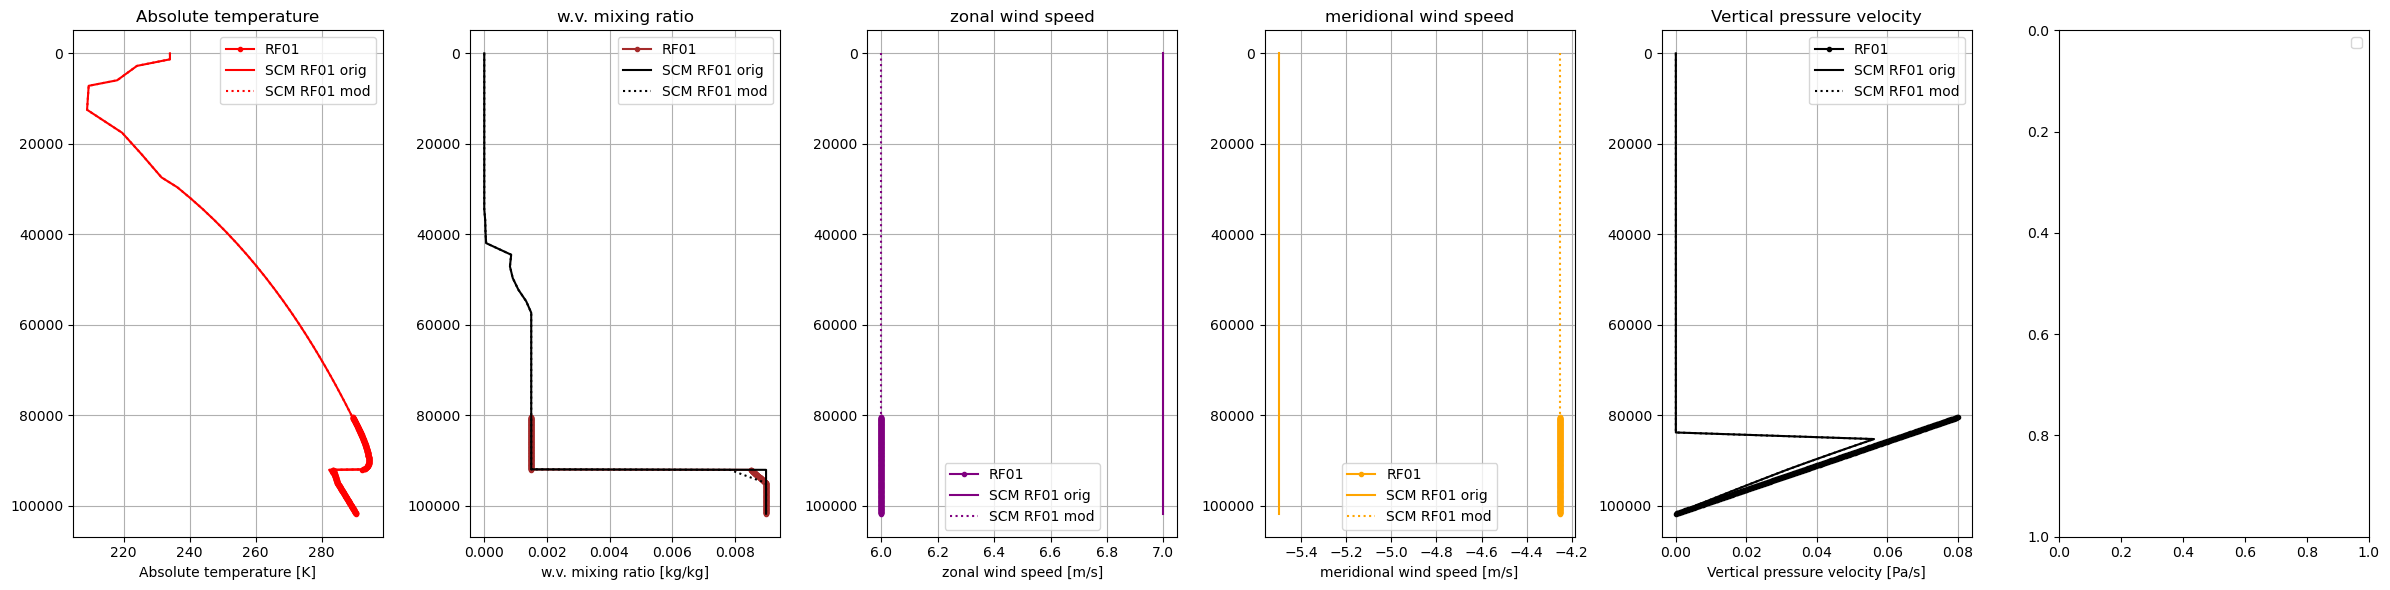

In [65]:
#--- RF01 SCM input
filename = "./DYCOMSrf01_4day_4scam.nc"
ds_scm = xr.open_dataset(filename)
ds_scm = ds_scm.isel(lon=0, lat=0, time=0)

ds_scm_rf01_mod = xr.open_dataset("./DYCOMSrf01_4day_4scam_yhc20250509.nc")
ds_scm_rf01_mod = ds_scm_rf01_mod.isel(lon=0, lat=0, time=0)

#--- RF01 profiles
z = np.arange(0,2000,5)  # meters
ds_rf01 = DYCOMS_RF_profiles(z, RF_choice="RF01")

#--- plot
ds_list=[ds_rf01, ds_scm, ds_scm_rf01_mod]
lg_labels=['RF01', 'SCM RF01 orig', 'SCM RF01 mod']
yy_list=['p', 'lev', 'lev']
keys_to_plot_list=[
    ['T', "q_v", 'u', 'v', 'omega'],   # for ds_rf01
    ['T', "q", 'u', 'v', 'omega'],    # for ds_scm
    ['T', "q", 'u', 'v', 'omega'],    # for ds_scm
]
linestyles=[None,'-', ':']
markers=['.', None, None]

fig, axes = plt.subplots(1, num_keys, figsize=(24, 6))
plot_profiles_from_multiple_ds(axes, ds_list, lg_labels,
                                   yy_list, keys_to_plot_list,
                                   linestyles=linestyles, 
                                   markers=markers)

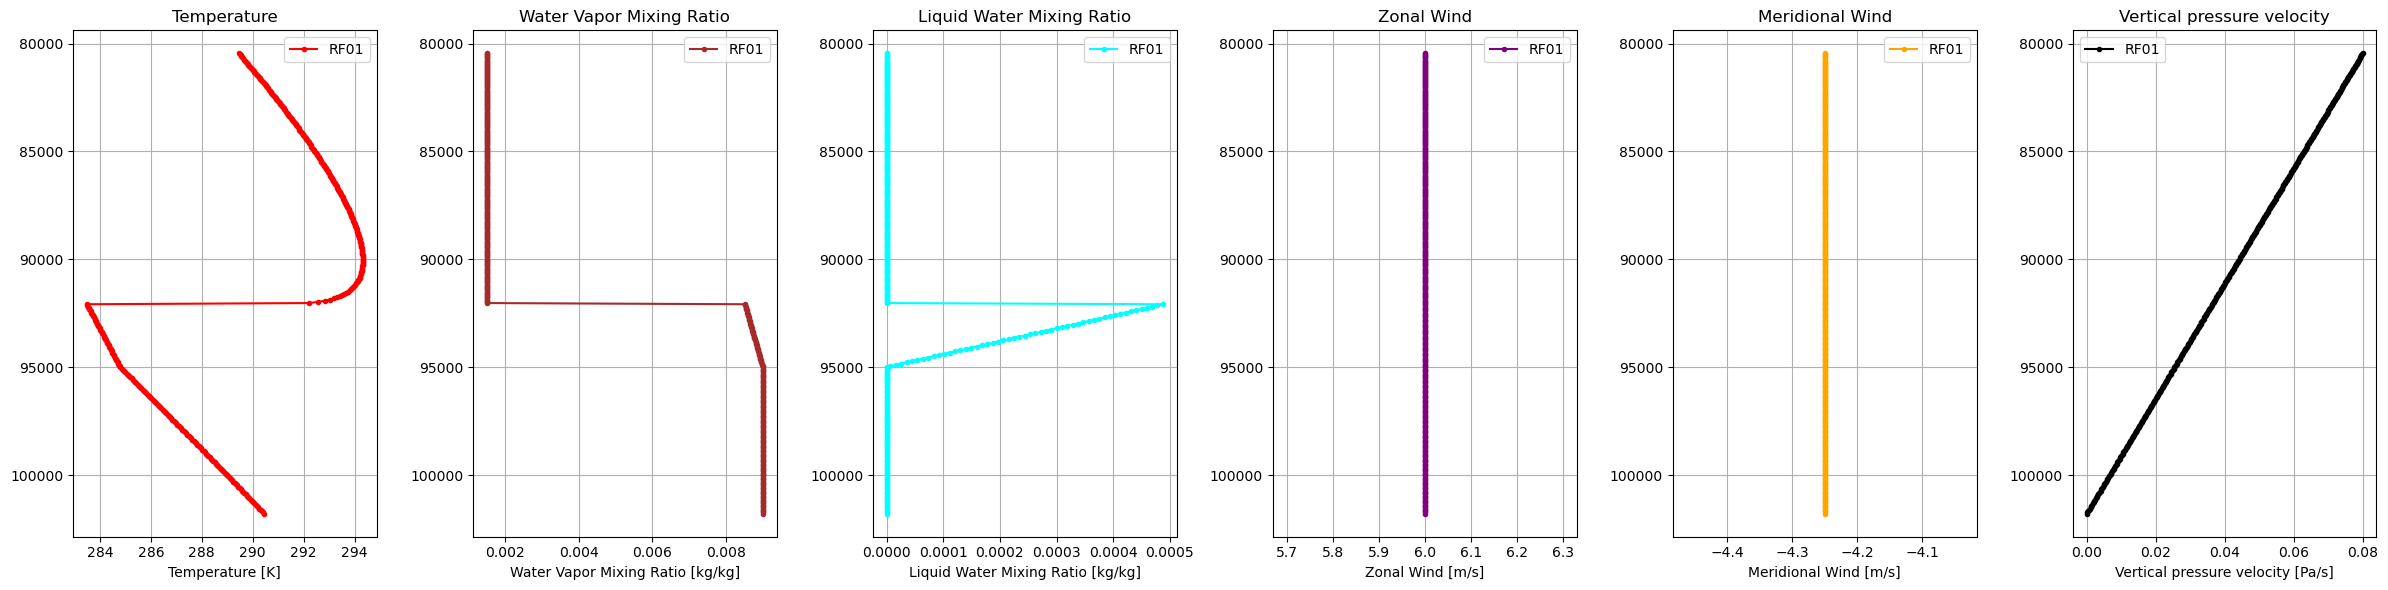

In [66]:
#--- plot
ds_list=[ds_rf01, ds_scm]
lg_labels=['RF01']
yy_list=['p']
keys_to_plot_list=[
    ['T', "q_v", 'q_l','u', 'v', 'omega'],   # for ds_rf01
]
linestyles=['-']
markers=['.']

fig, axes = plt.subplots(1, num_keys, figsize=(24, 6))
plot_profiles_from_multiple_ds(axes, ds_list, lg_labels,
                                   yy_list, keys_to_plot_list,
                                   linestyles=linestyles, 
                                   markers=markers)

## RF02

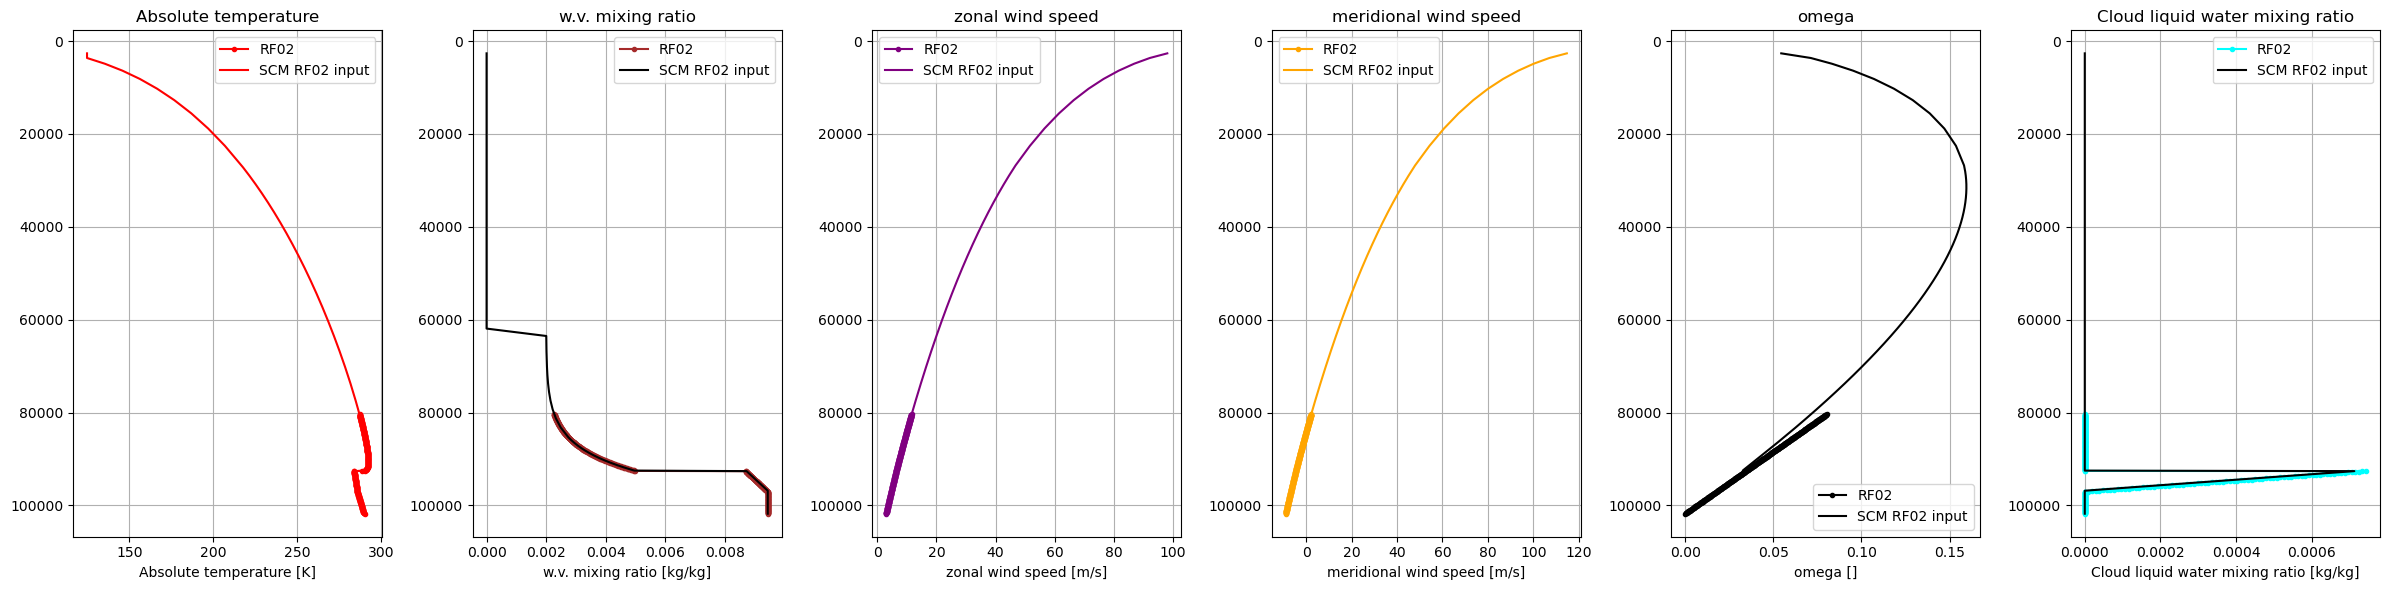

In [71]:
#--- RF01 SCM input
filename = "./DYCOMSrf02_48hr_4scam.nc"
ds_scm = xr.open_dataset(filename)
ds_scm = ds_scm.isel(lon=0, lat=0, time=0)

#--- RF01 profiles
z = np.arange(0,2000,5)  # meters
ds_rf02 = DYCOMS_RF_profiles(z, RF_choice="RF02")

#--- plot
ds_list=[ds_rf02, ds_scm]
lg_labels=['RF02', 'SCM RF02 input']
yy_list=['p', 'lev']
keys_to_plot_list=[
    ['T', "q_v", 'u', 'v', 'omega', 'q_l'],   # for ds_rf01
    ['T', "q", 'u', 'v', 'omega', "CLDLIQ"]    # for ds_scm
]
linestyles=[None,'-']
markers=['.', None]

fig, axes = plt.subplots(1, num_keys, figsize=(24, 6))
plot_profiles_from_multiple_ds(axes, ds_list, lg_labels,
                                   yy_list, keys_to_plot_list,
                                   linestyles=linestyles, 
                                   markers=markers)

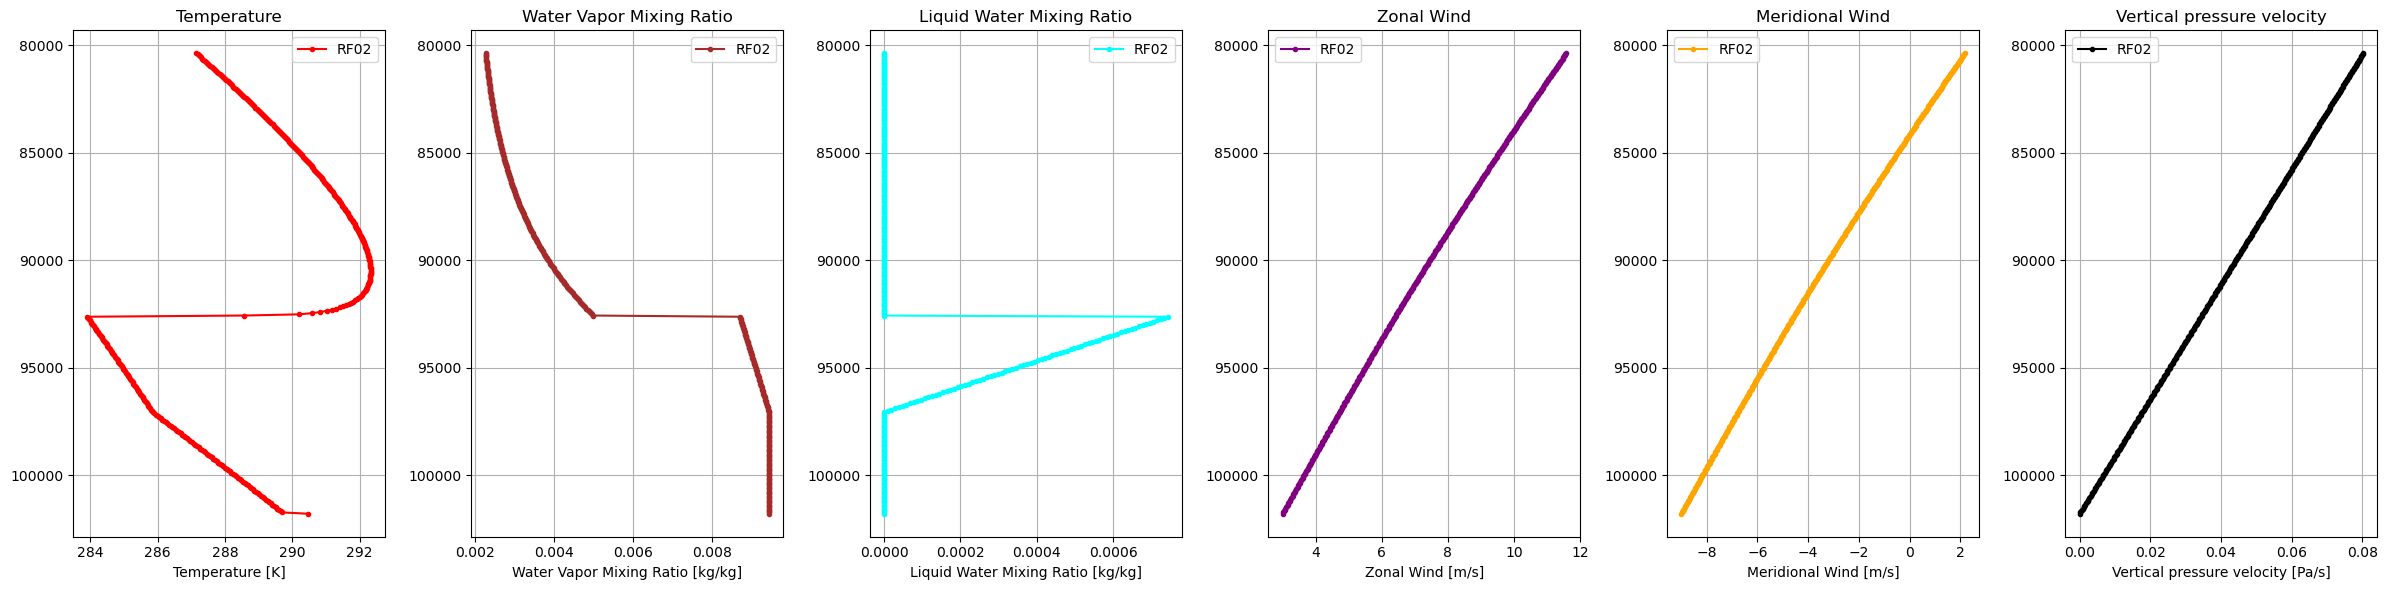

In [70]:
#--- plot
ds_list=[ds_rf02]
lg_labels=['RF02']
yy_list=['p']
keys_to_plot_list=[
    ['T', "q_v", 'q_l','u', 'v', 'omega'],   # for ds_rf01
]
linestyles=['-']
markers=['.']

fig, axes = plt.subplots(1, num_keys, figsize=(24, 6))
plot_profiles_from_multiple_ds(axes, ds_list, lg_labels,
                                   yy_list, keys_to_plot_list,
                                   linestyles=linestyles, 
                                   markers=markers)